In [181]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


Zadanie 1. Implementacja PCA z wykorzystaniem Scikit-Learn (zestaw danych z zadania
wprowadzającego).
1.1. Wstępne przetworzenie danych oraz standaryzacja.
1.2. Redukcja wymiarowości do dwóch wymiarów.
1.3. Dopasowanie transformatora i uzyskanie składowych głównych:
o Dopasowanie transformatora PCA do danych – przekształcenie oryginalnych danych
na dwie główne składowe, rzutując je na wektory własne odpowiadające dwóm
największym wartościom własnym.

In [182]:
df = pd.read_csv("data.csv").dropna(axis=1, how="all")
df['target'] = df['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
df.head()
#print(df.isnull().sum())

features = df.drop(columns=['id', 'diagnosis', 'target'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [183]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['target'] = df['target']

pca_df.head()

,PC1,PC2,target
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


In [184]:
explained_variance = pca.explained_variance_ratio_

1.4. Wizualizacja głównych składowych:
o Wykres punktowy z kolumną 'Target': dodaj kolory lub znaczniki według wartości
kolumny „Target”, aby sprawdzić, jak dobrze składowe główne rozróżniają klasy.

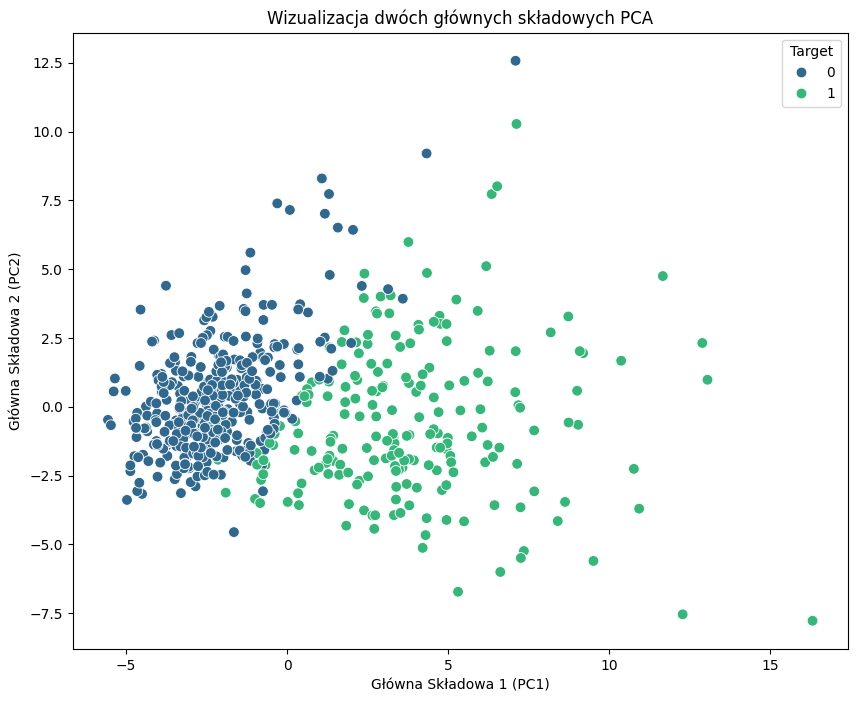

In [185]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='viridis', s=60)
plt.title("Wizualizacja dwóch głównych składowych PCA")
plt.xlabel("Główna Składowa 1 (PC1)")
plt.ylabel("Główna Składowa 2 (PC2)")
plt.legend(title="Target")
plt.show()


1.5. Wyświetlenie składowych i zależności:
1.5.1. Atrybut components_ – po dopasowaniu transformatora należy wyświetlić atrybut
components_, aby zobaczyć macierz składowych głównych. Składowe te
reprezentują wektory własne, które określają kierunki maksymalnej zmienności
danych.
1.5.2. Mapa cieplna – należy wykorzystać mapę cieplną do przedstawienia relacji między
składowymi głównymi a oryginalnymi zmiennymi. Każda zmienna wejściowa (z
30-wymiarowego zbioru danych) jest reprezentowana w odniesieniu do głównych
składowych.

In [186]:
print("Macierz składowych głównych (components_):\n", pca.components_)

Macierz składowych głównych (components_):
 [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


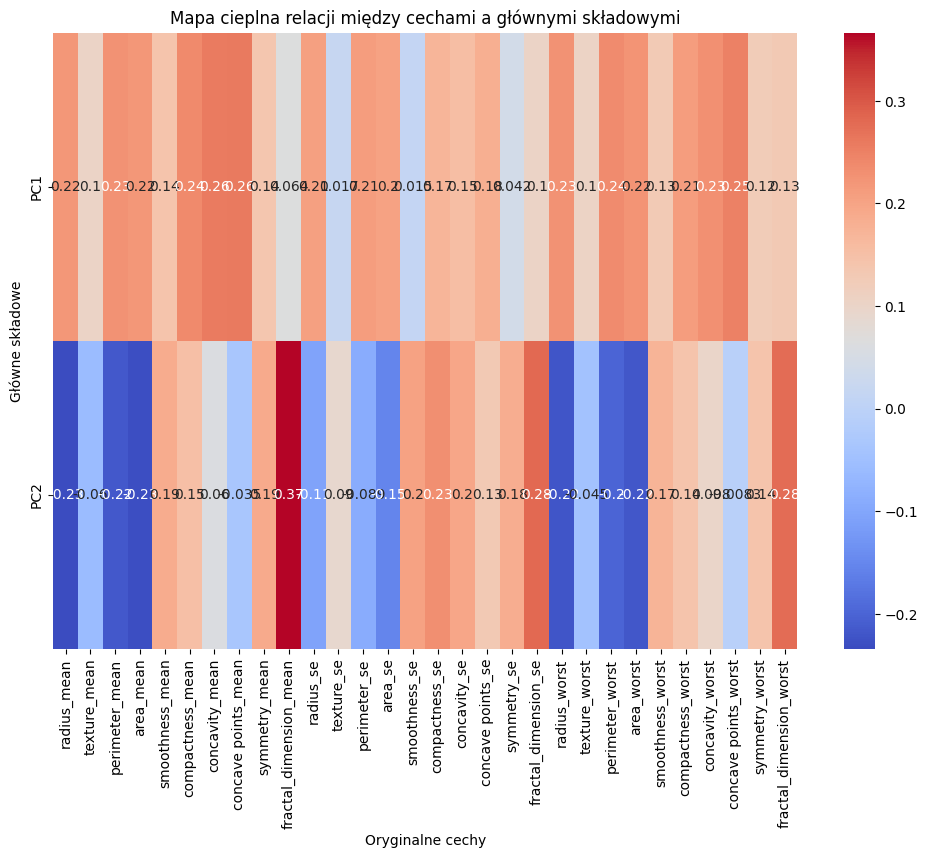

In [187]:
plt.figure(figsize=(12, 8))
sns.heatmap(pca.components_, cmap='coolwarm', annot=True, xticklabels=features.columns, yticklabels=['PC1', 'PC2'])
plt.title("Mapa cieplna relacji między cechami a głównymi składowymi")
plt.xlabel("Oryginalne cechy")
plt.ylabel("Główne składowe")
plt.show()


1.6. Analiza wariancji:
1.6.1. Wariancja składowych - jaki procent wariancji wyjaśniają poszczególne składowe
(PC1 i PC2).
1.6.2. Wariancja całkowita – jaki procent całkowitej wariancji danych jest wyjaśniany
przez dwie wybrane składowe.
1.6.3. Liczba składowych dla 95% i 99% wariancji – obliczenie liczby składowych, które
pozwalają wyjaśnić ponad 905% i 99% całkowitej wariancji.
1.6.4. Wykres wariancji od liczby składowych – zobrazowanie zależności między liczbą
składowych a wariancją, aby lepiej zrozumieć, jak szybko maleje wkład kolejnych
składowych w całkowitą wariancję danych.

In [188]:
explained_variance = pca.explained_variance_ratio_
print(f"Wariancja wyjaśniana przez PC1: {explained_variance[0]:.2%}")
print(f"Wariancja wyjaśniana przez PC2: {explained_variance[1]:.2%}")

Wariancja wyjaśniana przez PC1: 44.27%
Wariancja wyjaśniana przez PC2: 18.97%


In [189]:
total_variance = np.sum(explained_variance)
print(f"Łączna wariancja wyjaśniana przez PC1 i PC2: {total_variance:.2%}")

Łączna wariancja wyjaśniana przez PC1 i PC2: 63.24%


In [190]:
# PCA na pełnym zestawie cech
pca_full = PCA().fit(scaled_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
num_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Liczba składowych dla 95% wariancji: {num_components_95}")
print(f"Liczba składowych dla 99% wariancji: {num_components_99}")

Liczba składowych dla 95% wariancji: 10
Liczba składowych dla 99% wariancji: 17


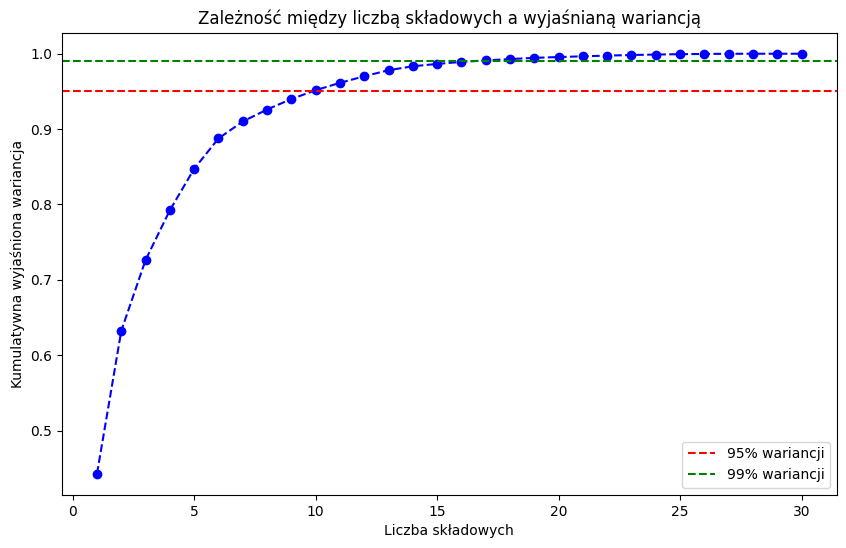

In [191]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Liczba składowych")
plt.ylabel("Kumulatywna wyjaśniona wariancja")
plt.title("Zależność między liczbą składowych a wyjaśnianą wariancją")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% wariancji")
plt.axhline(y=0.99, color='g', linestyle='--', label="99% wariancji")
plt.legend()
plt.show()


1.7. Przeprowadzenie PCA na danych oryginalnych (pomijając standaryzację w kroku 2.1)
i należy wykonać pozostałe kroki (od 2.2 do końca) na oryginalnych danych, aby
porównać wpływ standaryzacji na wyniki PCA.

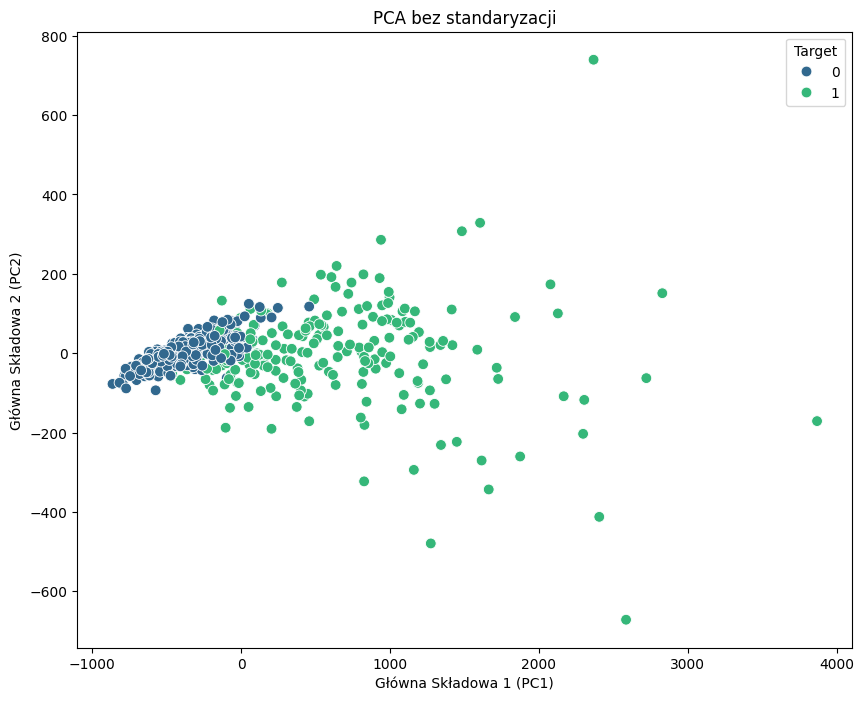

In [192]:
# PCA na niestandaryzowanych danych
pca_no_scaling = PCA(n_components=2)
principal_components_no_scaling = pca_no_scaling.fit_transform(features)
pca_df_no_scaling = pd.DataFrame(data=principal_components_no_scaling, columns=['PC1', 'PC2'])
pca_df_no_scaling['target'] = df['target']

# Wizualizacja
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df_no_scaling, x='PC1', y='PC2', hue='target', palette='viridis', s=60)
plt.title("PCA bez standaryzacji")
plt.xlabel("Główna Składowa 1 (PC1)")
plt.ylabel("Główna Składowa 2 (PC2)")
plt.legend(title="Target")
plt.show()


Zadanie 2. Implementacja analizy PCA dla danych obrazów cyfr.
Proszę o pobranie danych ze źródła:
https://archive.ics.uci.edu/dataset/81/pen+based+recognition+of+handwritten+digits
Baza danych zawiera 250 obrazów cyfr o wymiarach 8x8 pikseli. Po wczytaniu danych należy
wykonać poniższe kroki:
2.1. Przygotowanie danych:
2.1.1. Sprawdzenie kompletności danych.
2.1.2. Przygotowanie ramki danych piksele – utworzenie df_pixels.
2.1.3. Przykładowa reprezentacja obrazu – należy pobrać pierwszy wiersz danych z
obiektu df_pixels jako reprezentację jednego obrazu cyfry.
2.1.4. Wizualizacja obrazu – należy użyć Matplotlib lub Seaborn do wyświetlenia obrazu
cyfry z odpowiednią mapą kolorów, aby zobaczyć graficzną reprezentację wartości
pikseli.

In [193]:
data = pd.read_csv("digits.csv")
print(data.isnull().sum())

pixel_0_0       0
pixel_0_1       0
pixel_0_2       0
pixel_0_3       0
pixel_0_4       0
               ..
pixel_7_4       0
pixel_7_5       0
pixel_7_6       0
pixel_7_7       0
number_label    0
Length: 65, dtype: int64


In [194]:
# Wyodrębnienie danych pikseli, bez kolumny 'number_label'
df_pixels = data.drop(columns=['number_label'])

In [195]:
# Konwersja danych do typu numerycznego przed reshapingiem i wizualizacją
example_image = df_pixels.iloc[0].astype(float).values.reshape(8, 8)

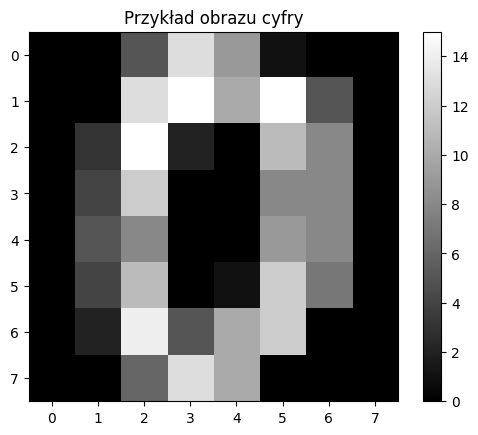

In [196]:
plt.imshow(example_image, cmap='gray')
plt.title("Przykład obrazu cyfry")
plt.colorbar()
plt.show()


2.2. Implementacja PCA:
2.2.1. Standaryzacja danych.
2.2.2. Redukcja wymiarowości do 2 składowych głównych (rzutowanie przestrzeni 64-
wymiarowej na przestrzeń dwuwymiarową).
2.2.3. Dopasowanie PCA do danych – dopasowanie transformatora PCA do zestawu
danych, w celu uzyskania dwóch głównych składowych.
2.2.4. Wyświetlenie atrybutu components_
2.2.5. Wariancja poszczególnych składowych – należy sprawdzić, ile wariancji wyjaśnia
każda z głównych składowych.
2.2.6. Wariancja dwóch składowych – określenie, ile całkowitej wariancji wyjaśniają dwie
składowe.

In [197]:
scaler = StandardScaler()
df_pixels_scaled = scaler.fit_transform(df_pixels)

In [198]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_pixels_scaled)

In [199]:
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
principal_df['number_label'] = data['number_label']

In [200]:
print("Wektory własne (components_):")
print(pca.components_)

Wektory własne (components_):
[[-0.          0.18223392  0.285868    0.22036967 -0.02516956 -0.00949725
  -0.0524765  -0.06269499  0.03470727  0.24553368  0.22915174 -0.10794381
   0.03620209  0.03871159 -0.08378077 -0.09277502  0.01669934  0.1367165
  -0.06305075 -0.12287927  0.14819348 -0.02348425 -0.1711997  -0.10420837
  -0.00394882 -0.1163897  -0.18820473  0.0658604   0.14353257 -0.12820705
  -0.18062075 -0.05270917 -0.         -0.23890251 -0.23500613 -0.00509137
  -0.01310881 -0.15911618 -0.12939416 -0.         -0.05559906 -0.18715707
  -0.15353371 -0.04682572 -0.11089272 -0.10720947  0.01792652 -0.00227271
  -0.02881729  0.040868    0.11027068  0.0318244  -0.07904945  0.06832147
   0.12124707  0.04877119 -0.00183586  0.16039569  0.27985301  0.19444929
   0.01777381  0.103198    0.1198106   0.07149362]
 [ 0.          0.04702701  0.0595648  -0.02080385  0.15590316  0.27413299
   0.24973251  0.14583207 -0.00102721  0.02761909  0.01450474 -0.09225537
   0.0572917   0.21410852  0.266

In [201]:
print("Wariancja wyjaśniana przez każdą składową:", pca.explained_variance_ratio_)
total_variance_explained = sum(pca.explained_variance_ratio_)
print("Całkowita wariancja wyjaśniana przez dwie składowe:", total_variance_explained)

Wariancja wyjaśniana przez każdą składową: [0.12033916 0.09561054]
Całkowita wariancja wyjaśniana przez dwie składowe: 0.2159497050083281


2.2.7. Liczba składowych dla 95% i 99% wariancji – wyznaczenie liczby składowych
potrzebnych do wyjaśnienia odpowiednio 95% i 99% wariancji.
2.2.8. Wizualizacja rozrzutu cyfr w dwuwymiarowej przestrzeni PCA – utwórz wykres
rozrzutu, na którym cyfry są oznaczone kolorami lub etykietami na podstawie
kolumny 'number_label'.
2.2.9. Analiza rozróżnialności cyfr – określenie, które cyfry są najlepiej rozróżnialne, a
które najsłabiej.
2.2.10. Możliwość klasyfikacji – ocena, czy dwie główne składowe mogą być
wystarczające do klasyfikacji cyfr.

In [202]:
# PCA z pełną liczbą składowych do obliczeń wariancji
pca_full = PCA().fit(df_pixels_scaled)
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

n_components_95 = (cumulative_variance >= 0.95).argmax() + 1
n_components_99 = (cumulative_variance >= 0.99).argmax() + 1
print("Liczba składowych dla 95% wariancji:", n_components_95)
print("Liczba składowych dla 99% wariancji:", n_components_99)

Liczba składowych dla 95% wariancji: 40
Liczba składowych dla 99% wariancji: 54


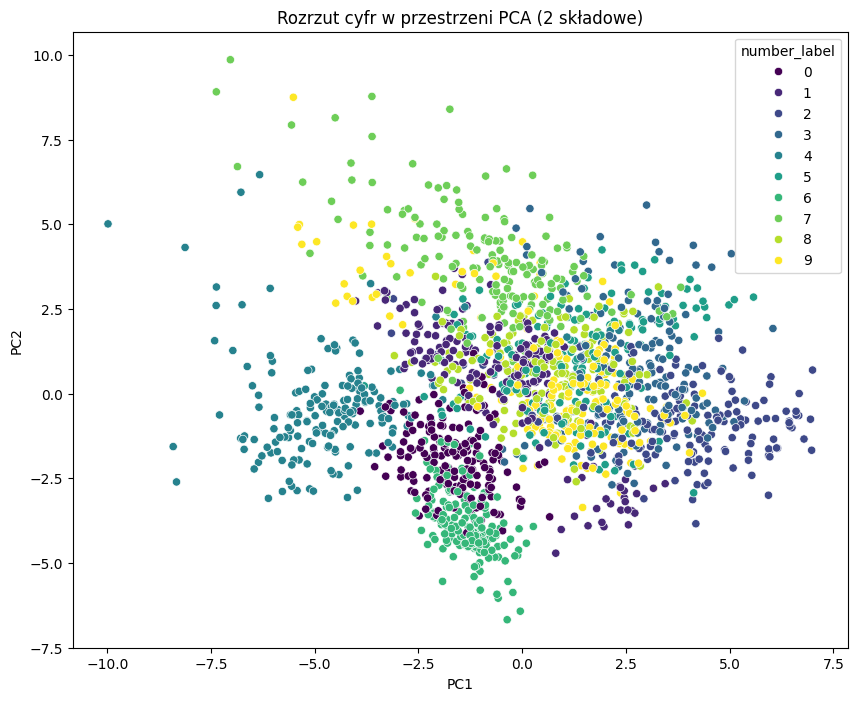

In [203]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=principal_df, x='PC1', y='PC2', hue='number_label', palette="viridis", legend="full")
plt.title("Rozrzut cyfr w przestrzeni PCA (2 składowe)")
plt.show()


2.3. Rozszerzenie PCA na trzy składowe główne:
2.3.1. PCA dla 3 składowych – wykonanie PCA na tym samym zbiorze danych, dla liczby
składowych ustawionych na 3.
2.3.2. Wariancja poszczególnych składowych – sprawdzenie wariancji wyjaśnianej przez
każdą z trzech głównych składowych.
2.3.3. Wariancja dla trzech składowych – ile całkowitej wariancji wyjaśniają trzy główne
składowe?
2.3.4. Wizualizacja w 3D – utworzenie wykresu 3D dla zbioru danych w przestrzeni trzech
głównych składowych PCA, na którym cyfry są oznaczone kolorami lub etykietami
na podstawie kolumny 'number_label'.
2.3.5. Analiza rozróżnialności cyfr – określenie, które cyfry są najlepiej rozróżnialne, a
które najsłabiej.

In [204]:
pca_3d = PCA(n_components=3)
principal_components_3d = pca_3d.fit_transform(df_pixels_scaled)
principal_df_3d = pd.DataFrame(data=principal_components_3d, columns=['PC1', 'PC2', 'PC3'])
principal_df_3d['number_label'] = data['number_label']

In [205]:
print("Wariancja wyjaśniana przez każdą z trzech składowych:", pca_3d.explained_variance_ratio_)
print("Całkowita wariancja wyjaśniana przez trzy składowe:", sum(pca_3d.explained_variance_ratio_))

Wariancja wyjaśniana przez każdą z trzech składowych: [0.12033916 0.09561054 0.08444415]
Całkowita wariancja wyjaśniana przez trzy składowe: 0.30039385393457363


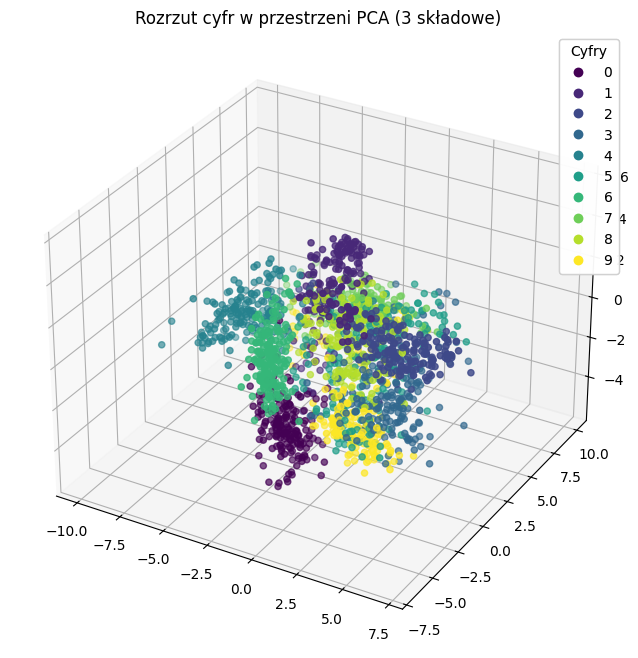

In [206]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(principal_df_3d['PC1'], principal_df_3d['PC2'], principal_df_3d['PC3'], c=principal_df_3d['number_label'], cmap="viridis", marker='o')
legend1 = ax.legend(*scatter.legend_elements(), title="Cyfry")
ax.add_artist(legend1)
plt.title("Rozrzut cyfr w przestrzeni PCA (3 składowe)")
plt.show()

2.4. Przeprowadzenie PCA na danych oryginalnych (od kroku punktu 2.2. kroku 2.2.2
pomijając standaryzację, do punktu 2.3. włącznie).

In [207]:
pca_o = PCA(n_components=2)
principal_components_o = pca_o.fit_transform(df_pixels)

principal_df_o = pd.DataFrame(data=principal_components_o, columns=['PC1', 'PC2'])
principal_df_o['number_label'] = data['number_label']

In [208]:
print("Wektory własne (components_):")
print(pca_o.components_)

Wektory własne (components_):
[[ 0.00000000e+00 -1.73094651e-02 -2.23428835e-01 -1.35913304e-01
  -3.30323092e-02 -9.66340844e-02 -8.32943805e-03  2.26900082e-03
  -3.20516495e-04 -1.19308905e-01 -2.44451676e-01  1.48512745e-01
  -4.67319410e-02 -2.17740744e-01 -1.48136776e-02  4.47779518e-03
  -4.94136398e-05 -7.95419375e-02  8.33951454e-02  2.15915342e-01
  -1.72126801e-01 -1.63712098e-01  2.86444452e-02  4.23251803e-03
   9.85488574e-05  6.42319144e-02  2.54093316e-01 -3.56771026e-02
  -2.09462569e-01 -4.31311420e-02  5.13118688e-02  2.13422732e-04
   0.00000000e+00  1.59950883e-01  3.68690774e-01  1.64406827e-01
   8.52007908e-02  3.72982855e-02  2.15866980e-02  0.00000000e+00
   1.28865585e-03  1.06945287e-01  3.03067457e-01  2.47813041e-01
   2.09637296e-01  1.22325219e-02 -3.69458497e-02  1.61485028e-03
   6.93023548e-04 -8.35144239e-03 -5.58598986e-02  9.30534169e-02
   1.07387720e-01 -1.37734565e-01 -6.32879466e-02  9.61671077e-04
   9.55079131e-06 -1.40786840e-02 -2.35675488e

In [209]:
print("Wariancja wyjaśniana przez każdą składową:", pca_o.explained_variance_ratio_)
total_variance_explained_o = sum(pca_o.explained_variance_ratio_)
print("Całkowita wariancja wyjaśniana przez dwie składowe:", total_variance_explained_o)

Wariancja wyjaśniana przez każdą składową: [0.14890594 0.13618771]
Całkowita wariancja wyjaśniana przez dwie składowe: 0.2850936482369929


In [210]:
# PCA z pełną liczbą składowych do obliczeń wariancji
pca_full_o = PCA().fit(df_pixels)
cumulative_variance_o = pca_full_o.explained_variance_ratio_.cumsum()

n_components_95 = (cumulative_variance_o >= 0.95).argmax() + 1
n_components_99 = (cumulative_variance_o >= 0.99).argmax() + 1
print("Liczba składowych dla 95% wariancji:", n_components_95)
print("Liczba składowych dla 99% wariancji:", n_components_99)

Liczba składowych dla 95% wariancji: 29
Liczba składowych dla 99% wariancji: 41


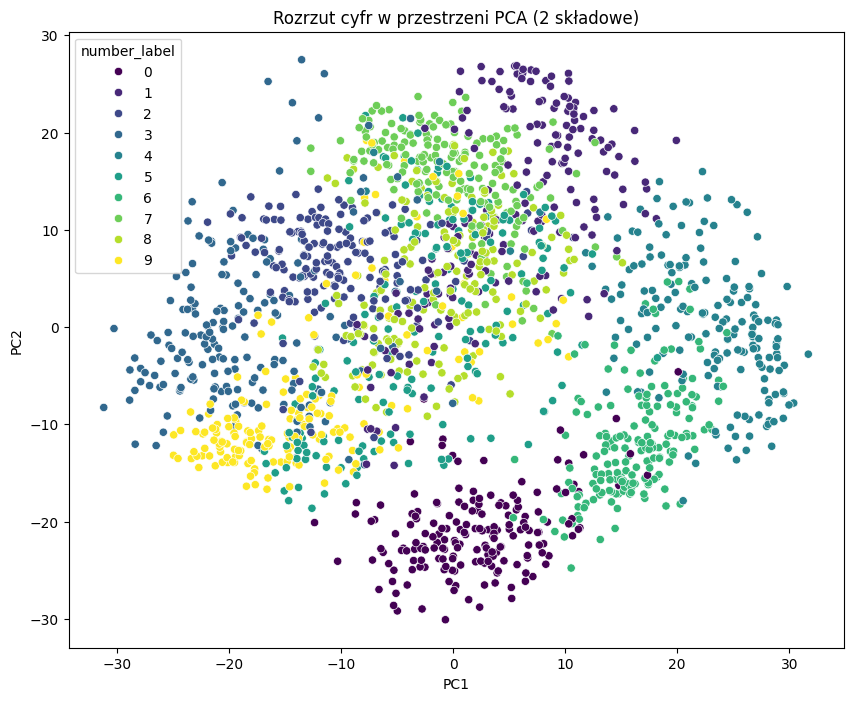

In [211]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=principal_df_o, x='PC1', y='PC2', hue='number_label', palette="viridis", legend="full")
plt.title("Rozrzut cyfr w przestrzeni PCA (2 składowe)")
plt.show()


In [212]:
pca_3d_o = PCA(n_components=3)
principal_components_3d_o = pca_3d_o.fit_transform(df_pixels)
principal_df_3d_o = pd.DataFrame(data=principal_components_3d_o, columns=['PC1', 'PC2', 'PC3'])
principal_df_3d_o['number_label'] = data['number_label']

In [213]:
print("Wariancja wyjaśniana przez każdą z trzech składowych:", pca_3d_o.explained_variance_ratio_)
print("Całkowita wariancja wyjaśniana przez trzy składowe:", sum(pca_3d_o.explained_variance_ratio_))

Wariancja wyjaśniana przez każdą z trzech składowych: [0.14890594 0.13618771 0.11794594]
Całkowita wariancja wyjaśniana przez trzy składowe: 0.40303958587675076


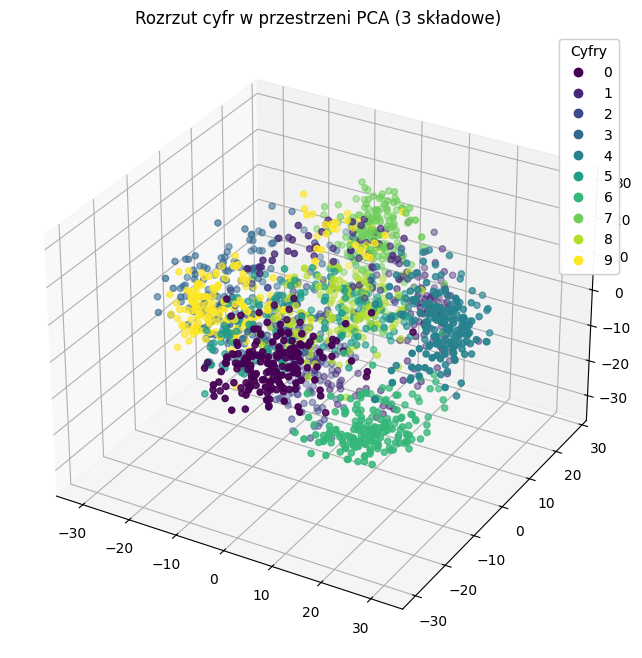

In [214]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(principal_df_3d_o['PC1'], principal_df_3d_o['PC2'], principal_df_3d_o['PC3'], c=principal_df_3d_o['number_label'], cmap="viridis", marker='o')
legend1 = ax.legend(*scatter.legend_elements(), title="Cyfry")
ax.add_artist(legend1)
plt.title("Rozrzut cyfr w przestrzeni PCA (3 składowe)")
plt.show()